<a href="https://colab.research.google.com/github/naveprof-ops/Nandini_verma_JECRC_CEI/blob/main/Nandini_verma_week_3_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
rohan0301_unsupervised_learning_on_country_data_path = kagglehub.dataset_download('rohan0301/unsupervised-learning-on-country-data')

print('Data source import complete.')


Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
Data source import complete.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, silhouette_score)
import gc
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/unsupervised-learning-on-country-data/data-dictionary.csv


In [11]:
df = pd.read_csv('/kaggle/input/unsupervised-learning-on-country-data/Country-data.csv')
print("Shape:", df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


=== Missing Values ===
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

=== Statistical Summary ===
       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.810000    0.065900     609.000000   
25%      8.250000   23.800000    4.920000   30.200000    3355.000000   
50%     19.300000   35.000000    6.320000   43.300000    9960.000000   
75%     62.100000   51.350000    8.600000   58.750000   22800.000000   
max    208.000000  200.000000   17.900000  174.000000  125000.000000   

        inflation  life_expec   total_fer           gdpp  
count  167.000000  167.000000  167.000000     167.000000  
mean    

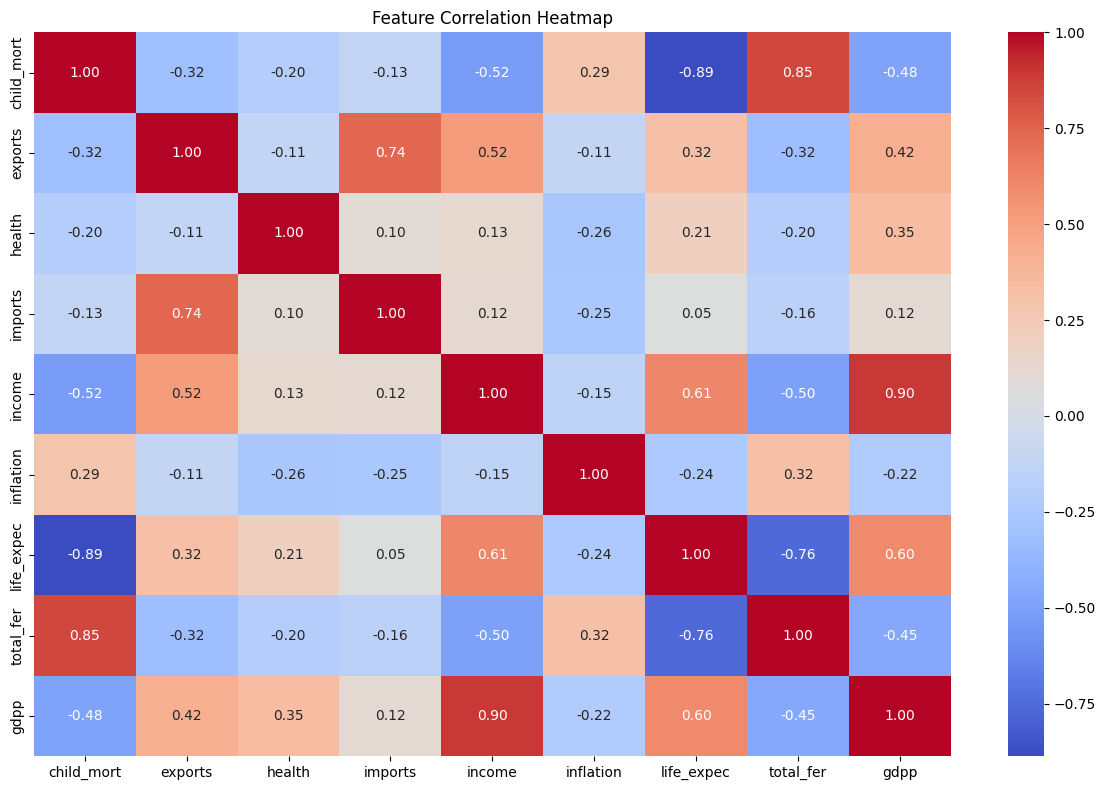

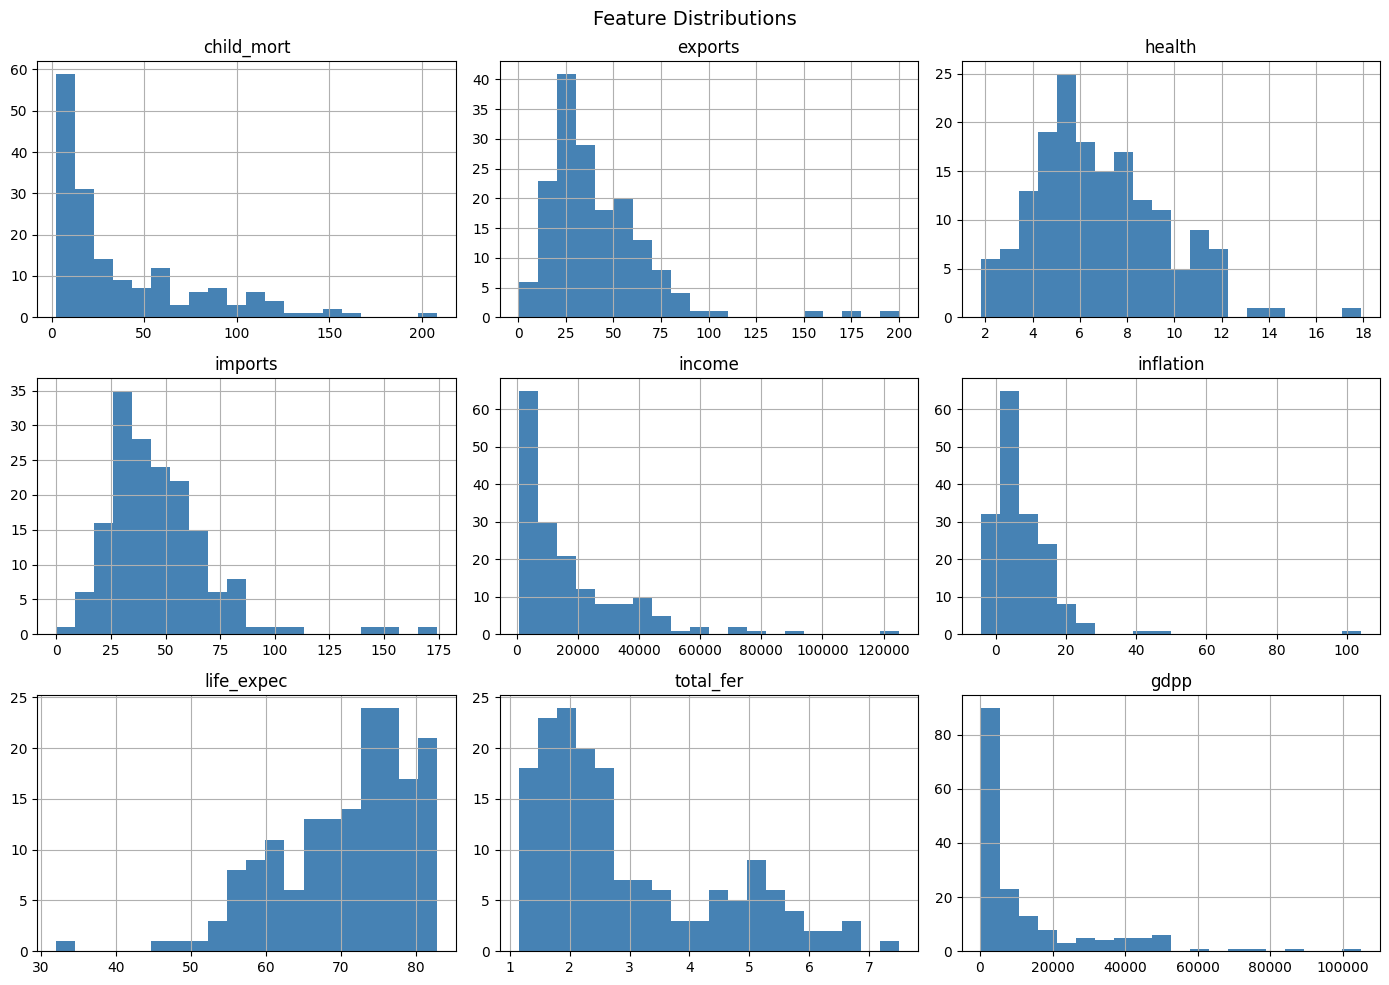

In [12]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Statistical Summary ===")
print(df.describe())

plt.figure(figsize=(12, 8))
sns.heatmap(df.drop('country', axis=1).corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

df.drop('country', axis=1).hist(bins=20, figsize=(14, 10), color='steelblue')
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
features = df.drop('country', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print("Scaling done. Shape:", X_scaled.shape)

Scaling done. Shape: (167, 9)


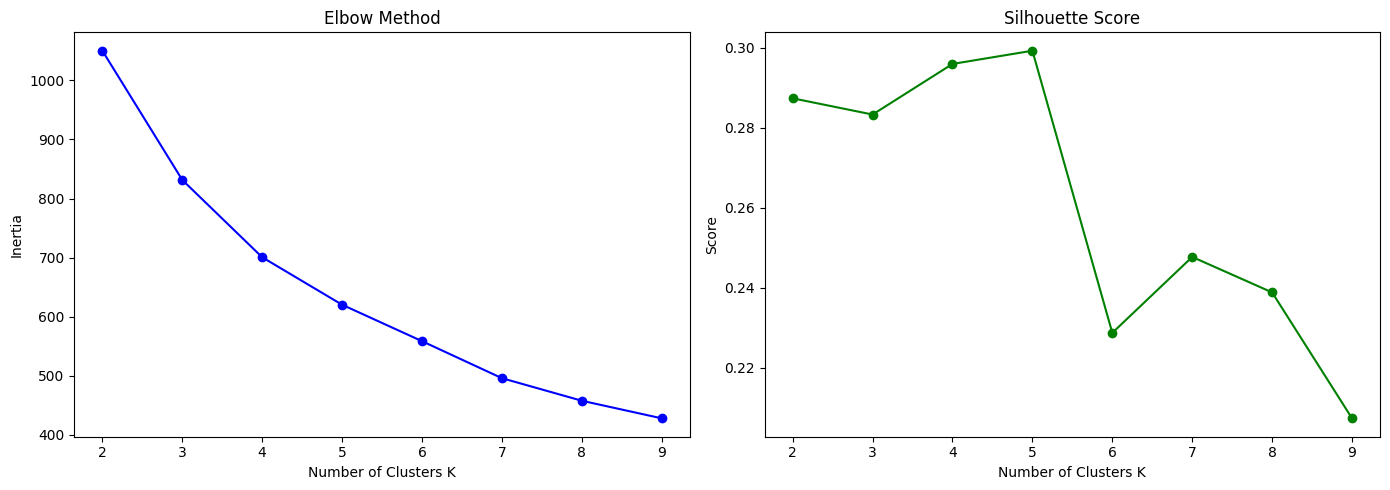

Cluster Distribution:
KMeans_Cluster
2    84
1    47
0    36
Name: count, dtype: int64
Silhouette Score: 0.2833


In [14]:
inertia = []
silhouette = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters K")
axes[0].set_ylabel("Inertia")

axes[1].plot(K_range, silhouette, 'go-')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters K")
axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Cluster Distribution:\n{df['KMeans_Cluster'].value_counts()}")
print(f"Silhouette Score: {silhouette_score(X_scaled, df['KMeans_Cluster']):.4f}")

In [15]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print("DBSCAN Cluster Distribution:")
print(df['DBSCAN_Cluster'].value_counts())
print(f"Noise points: {(df['DBSCAN_Cluster'] == -1).sum()}")

DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64
Noise points: 30


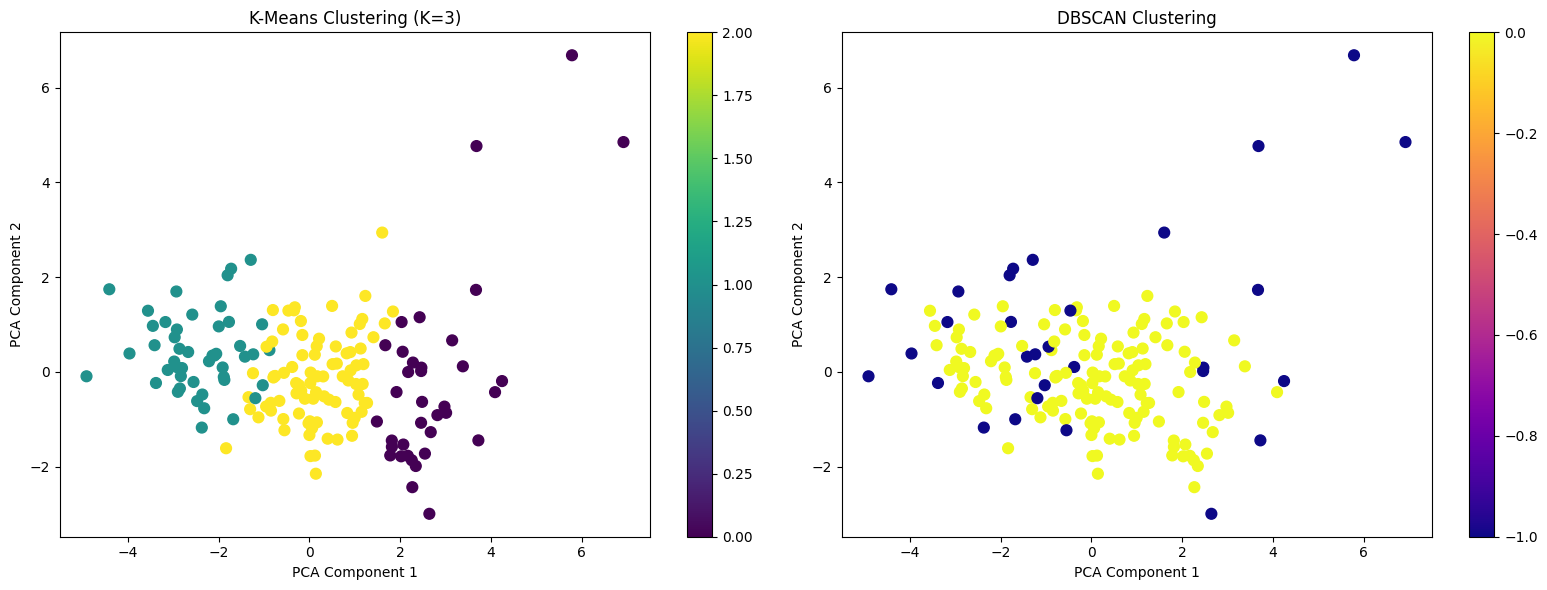

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=df['KMeans_Cluster'], cmap='viridis', s=60)
axes[0].set_title(f"K-Means Clustering (K={best_k})")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=df['DBSCAN_Cluster'], cmap='plasma', s=60)
axes[1].set_title("DBSCAN Clustering")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

=== Cluster Profiles ===
                child_mort    income      gdpp  life_expec  inflation
KMeans_Cluster                                                       
0                     5.00  45672.22  42494.44       80.13       2.67
1                    92.96   3942.40   1922.38       59.19      12.02
2                    21.93  12305.60   6486.45       72.81       7.60


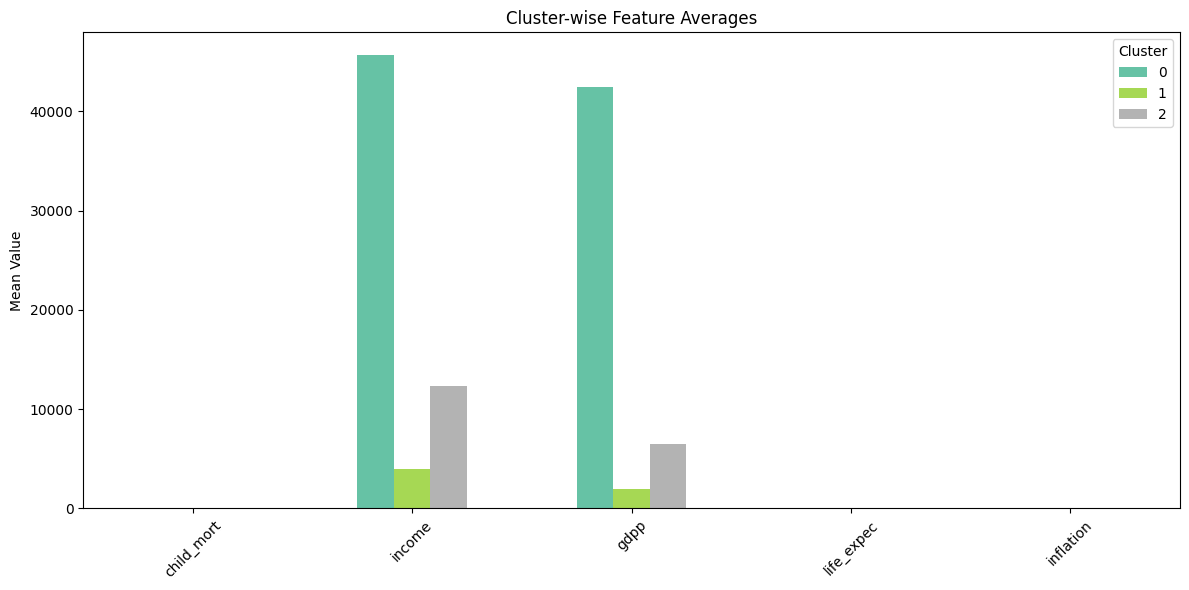


Segment Distribution:
Segment
Under-developed    84
Developed          47
Developing         36
Name: count, dtype: int64


In [17]:
cluster_profile = df.groupby('KMeans_Cluster')[
    ['child_mort', 'income', 'gdpp', 'life_expec', 'inflation']
].mean().round(2)

print("=== Cluster Profiles ===")
print(cluster_profile)

cluster_profile.T.plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title("Cluster-wise Feature Averages")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

segment_map = {0: "Developing", 1: "Developed", 2: "Under-developed"}
df['Segment'] = df['KMeans_Cluster'].map(segment_map)
print("\nSegment Distribution:")
print(df['Segment'].value_counts())

In [18]:
le = LabelEncoder()
y = le.fit_transform(df['KMeans_Cluster'])
X = scaler.fit_transform(df.drop(['country', 'KMeans_Cluster',
                                   'DBSCAN_Cluster', 'Segment'], axis=1))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 133 | Test: 34


=== Random Forest ===
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



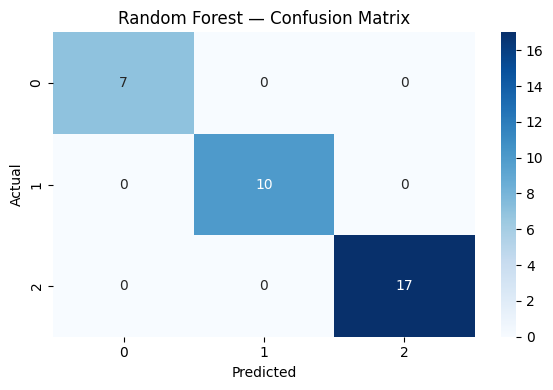

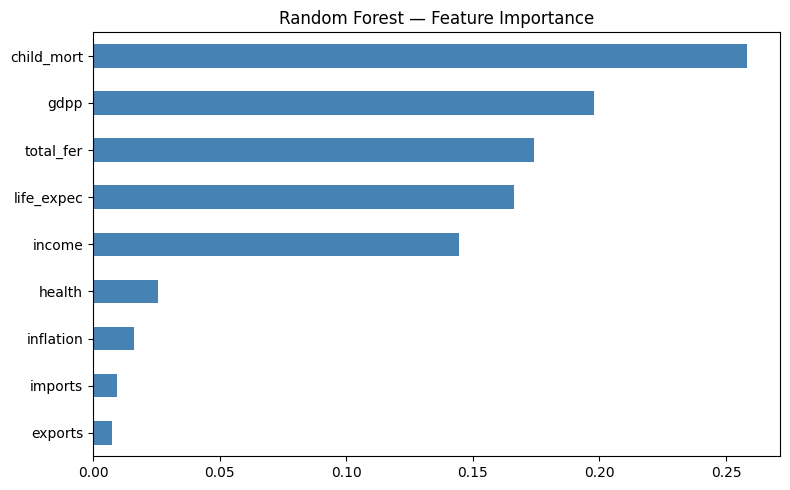

In [19]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, rf_preds),
            annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

feat_names = ['child_mort','exports','health','imports',
              'income','inflation','life_expec','total_fer','gdpp']
feat_imp = pd.Series(rf.feature_importances_, index=feat_names).sort_values()
feat_imp.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title("Random Forest — Feature Importance")
plt.tight_layout()
plt.show()

=== XGBoost ===
Accuracy: 0.9706
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



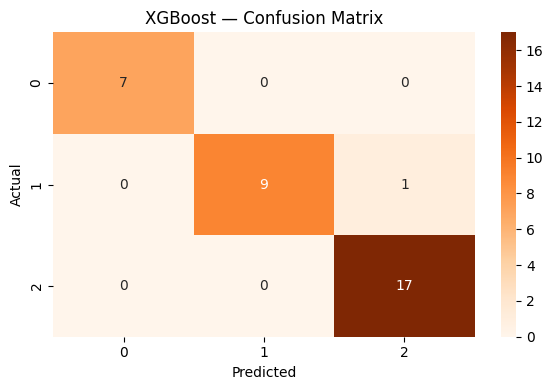

59878

In [20]:
xgb = XGBClassifier(n_estimators=100, max_depth=4,
                    learning_rate=0.1, random_state=42,
                    eval_metric='mlogloss')
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

print("=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print(classification_report(y_test, xgb_preds))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, xgb_preds),
            annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
gc.collect()

=== Model Comparison ===
        Model  Accuracy
Random Forest  1.000000
      XGBoost  0.970588


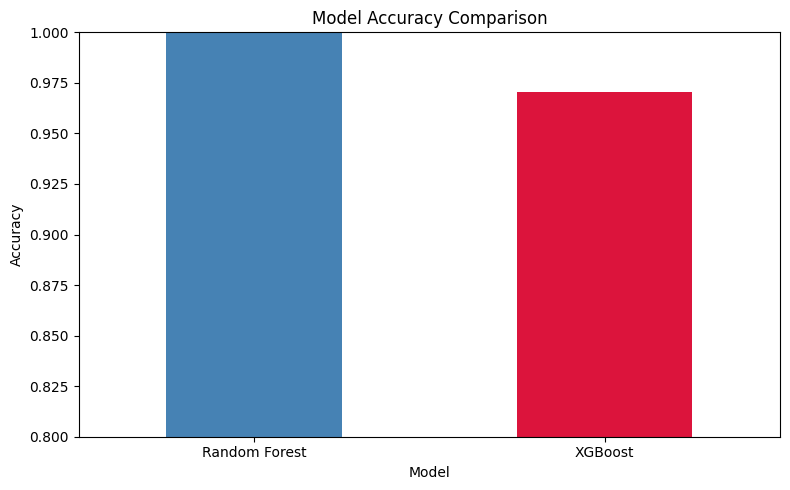


=== Final Summary ===
Total Countries     : 167
Features Used       : 9
K-Means Clusters    : 3
DBSCAN Noise Points : 30
Best Model          : Random Forest
Best Accuracy       : 1.0000


In [21]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ]
})

print("=== Model Comparison ===")
print(results.to_string(index=False))

results.set_index('Model')['Accuracy'].plot(
    kind='bar', figsize=(8, 5),
    color=['steelblue', 'crimson'], ylim=(0.8, 1.0))
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n=== Final Summary ===")
print(f"Total Countries     : {len(df)}")
print(f"Features Used       : 9")
print(f"K-Means Clusters    : {best_k}")
print(f"DBSCAN Noise Points : {(df['DBSCAN_Cluster']==-1).sum()}")
print(f"Best Model          : {results.loc[results['Accuracy'].idxmax(), 'Model']}")
print(f"Best Accuracy       : {results['Accuracy'].max():.4f}")